In [ ]:
!pip install pyclustering
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, BisectingKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, accuracy_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import calculate_distance_matrix
from sklearn.datasets import make_blobs

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=d84119ea6861f7c5e3396caae5db93b8d4574508c79dfdae3c351fd842af2673
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering


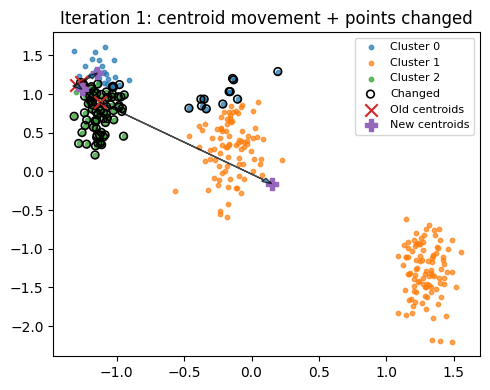

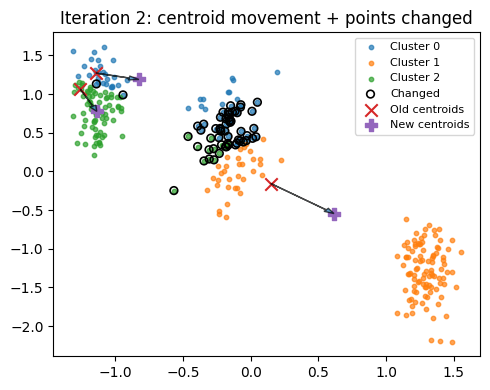

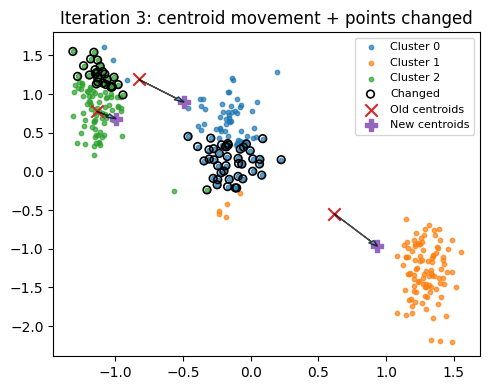

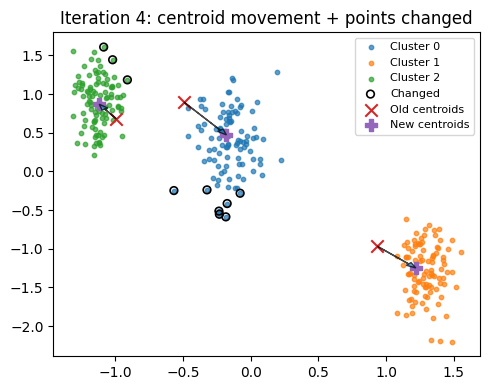

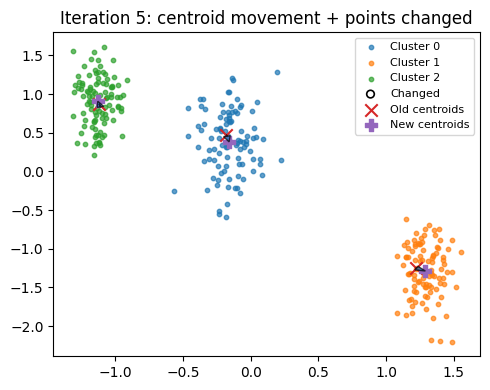

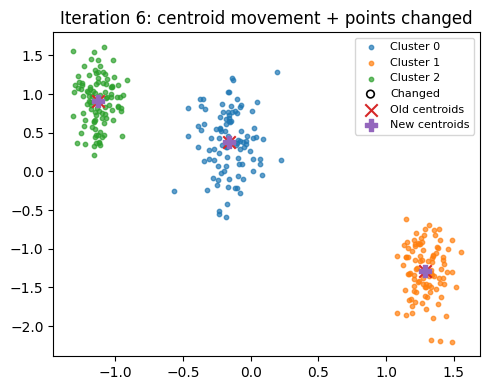

In [ ]:

# Visual demo on small 2D blobs (only for pedagogy)
X2d, _ = make_blobs(n_samples=300, centers=3, cluster_std=[0.7, 1.0, 0.8], random_state=7)
X2d = StandardScaler().fit_transform(X2d)

rng = np.random.default_rng(0)
K_demo = 3

# Initialize centroids
centroids = X2d[rng.choice(len(X2d), size=K_demo, replace=False)].copy()

def assign_labels(X, cents):
    d2 = np.sum((X[:, None, :] - cents[None, :, :])**2, axis=2)
    return d2.argmin(axis=1)

labels = assign_labels(X2d, centroids)
max_iter = 10

for it in range(max_iter):
    old_centroids = centroids.copy()
    # Update centroids
    new_centroids = np.vstack([X2d[labels == k].mean(axis=0) for k in range(K_demo)])
    # Reassign
    old_labels = labels.copy()
    labels = assign_labels(X2d, new_centroids)
    changed = labels != old_labels

    # Plot
    plt.figure(figsize=(5,4))
    for k in range(K_demo):
        pts = X2d[labels == k]
        plt.scatter(pts[:,0], pts[:,1], s=10, alpha=0.7, label=f'Cluster {k}')
    plt.scatter(X2d[changed,0], X2d[changed,1], s=30, facecolors='none', edgecolors='k', linewidths=1.2, label='Changed')
    plt.scatter(old_centroids[:,0], old_centroids[:,1], marker='x', s=80, label='Old centroids')
    plt.scatter(new_centroids[:,0], new_centroids[:,1], marker='P', s=80, label='New centroids')
    for (ox,oy),(nx,ny) in zip(old_centroids, new_centroids):
        plt.arrow(ox, oy, nx-ox, ny-oy, head_width=0.05, length_includes_head=True, alpha=0.7)
    plt.title(f'Iteration {it+1}: centroid movement + points changed')
    plt.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

    if np.allclose(new_centroids, old_centroids):
        break
    centroids = new_centroids


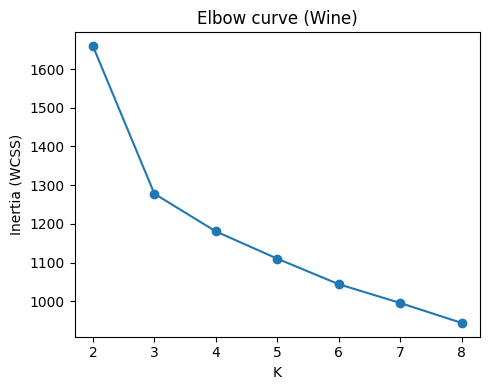

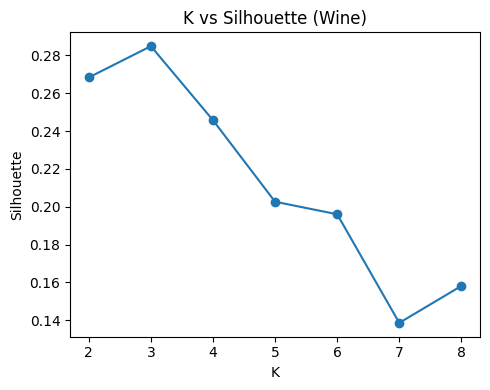

Best K by silhouette: 3


In [ ]:

wine = load_wine()
Xw = StandardScaler().fit_transform(wine.data)

Ks = range(2, 9)
inertias, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(Xw)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xw, labels))

plt.figure(figsize=(5,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel('K'); plt.ylabel('Inertia (WCSS)'); plt.title('Elbow curve (Wine)')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5,4))
plt.plot(Ks, sils, marker='o')
plt.xlabel('K'); plt.ylabel('Silhouette'); plt.title('K vs Silhouette (Wine)')
plt.tight_layout(); plt.show()

best_k = Ks[int(np.argmax(sils))]
print("Best K by silhouette:", best_k)



=== Full Results ===
                    Method  Silhouette          MSE  Accuracy  Time (s)
0                   KMeans    0.284859  1277.928489  0.966292  0.057532
1                 KMeans++    0.284859  1277.928489  0.966292  0.005497
2          MiniBatchKMeans    0.279223  1288.243828  0.938202  0.023533
3          BisectingKMeans    0.265949  1315.862310  0.882022  0.015859
4  KMedoids (pyclustering)    0.265977  1312.625089  0.904494  0.266049

=== Rankings (1 = Best) ===
                         Silhouette  MSE  Accuracy  Time (s)
Method                                                      
KMeans                          1.5  1.5       1.5       4.0
KMeans++                        1.5  1.5       1.5       1.0
MiniBatchKMeans                 3.0  3.0       3.0       3.0
BisectingKMeans                 5.0  5.0       5.0       2.0
KMedoids (pyclustering)         4.0  4.0       4.0       5.0


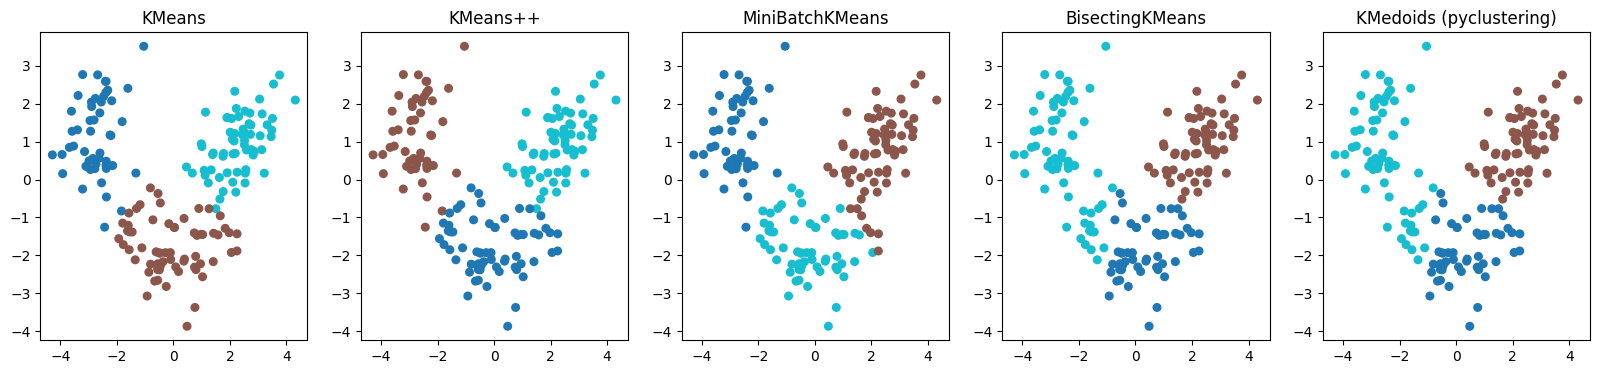

In [ ]:
# -----------------------------
# Load and preprocess dataset
# -----------------------------
wine = load_wine()
X = wine.data
y_true = wine.target
X_scaled = StandardScaler().fit_transform(X)

n_clusters = len(np.unique(y_true))

# -----------------------------
# Define models
# -----------------------------
models = {
    "KMeans": KMeans(n_clusters=n_clusters, init="random", random_state=42),
    "KMeans++": KMeans(n_clusters=n_clusters, init="k-means++", random_state=42),
    "MiniBatchKMeans": MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=32),
    "BisectingKMeans": BisectingKMeans(n_clusters=n_clusters, random_state=42),
}

results = []

# -----------------------------
# Run sklearn clustering models
# -----------------------------
for name, model in models.items():
    start_time = time.time()
    labels = model.fit_predict(X_scaled)
    exec_time = time.time() - start_time

    # Metrics
    sil = silhouette_score(X_scaled, labels)
    mse = model.inertia_ if hasattr(model, "inertia_") else np.sum((X_scaled - model.cluster_centers_[labels])**2)

    # Align cluster labels with Hungarian algorithm # READ MORE ABOUT IT
    cm = confusion_matrix(y_true, labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = dict(zip(col_ind, row_ind))
    aligned_labels = np.array([mapping[l] for l in labels])
    acc = accuracy_score(y_true, aligned_labels)

    results.append([name, sil, mse, acc, exec_time])

# -----------------------------
# K-Medoids with pyclustering
# -----------------------------
start_time = time.time()

# distance matrix required for pyclustering
dist_matrix = calculate_distance_matrix(X_scaled.tolist())
# randomly initialize medoids
initial_medoids = np.random.choice(len(X_scaled), n_clusters, replace=False).tolist()

kmedoids_instance = kmedoids(dist_matrix, initial_medoids, data_type='distance_matrix')
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()

labels = np.zeros(len(X_scaled), dtype=int)
for cluster_id, cluster in enumerate(clusters):
    for idx in cluster:
        labels[idx] = cluster_id

exec_time = time.time() - start_time

# Metrics
sil = silhouette_score(X_scaled, labels)
# manually compute cluster centers for MSE
centers = np.array([X_scaled[cluster].mean(axis=0) for cluster in clusters])
mse = np.sum([np.sum((X_scaled[cluster] - centers[i])**2) for i, cluster in enumerate(clusters)])

# Align labels
cm = confusion_matrix(y_true, labels)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = dict(zip(col_ind, row_ind))
aligned_labels = np.array([mapping[l] for l in labels])
acc = accuracy_score(y_true, aligned_labels)

results.append(["KMedoids (pyclustering)", sil, mse, acc, exec_time])

# -----------------------------
# Results DataFrame
# -----------------------------
df_results = pd.DataFrame(
    results,
    columns=["Method", "Silhouette", "MSE", "Accuracy", "Time (s)"]
)
print("\n=== Full Results ===")
print(df_results)

# -----------------------------
# Ranking summary
# -----------------------------
ranking = df_results.copy()
ranking["Silhouette"] = ranking["Silhouette"].rank(ascending=False)
ranking["MSE"] = ranking["MSE"].rank(ascending=True)
ranking["Accuracy"] = ranking["Accuracy"].rank(ascending=False)
ranking["Time (s)"] = ranking["Time (s)"].rank(ascending=True)

print("\n=== Rankings (1 = Best) ===")
print(ranking.set_index("Method"))

# -----------------------------
# PCA 2D visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, len(models) + 1, figsize=(20, 4))
for ax, (name, model) in zip(axes[:-1], models.items()):
    labels = model.fit_predict(X_scaled)
    ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=30)
    ax.set_title(name)

# K-Medoids plot
ax = axes[-1]
ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=30)
ax.set_title("KMedoids (pyclustering)")

plt.show()
